# Motion classification on the Thingy:53

**Author:** Dr. Le Viet Duc, Minh-Thanh Nguyen

**Copyright:** © 2026 University of Twente. All rights reserved.

**License & Usage Terms:**
This notebook and its contents are provided strictly for educational purposes within the context of the **Internet-of-Things** course.

- **Permitted:** Students enrolled in this course may run, modify, and save a personal copy of this notebook for their own educational use and assignment submission.

- **Prohibited:** You may not distribute, publish, or share this material publicly. This includes, but is not limited to, uploading to public GitHub repositories, course-sharing websites (e.g., CourseHero, Chegg), or public Google Drive folders.

Unauthorized distribution constitutes an academic integrity violation and a breach of intellectual property rights.

In this lab you'll train a neural network for the motion classification from
accelerometer data, and export it so it can run on the Thingy:53 itself.

In previous steps, you already collected the data, please export, download and
extract it into the same folder that you are running this notebook. In this
example, the dataset is already recorded and sitting in the `training/` and
`testing/` folders with three motions (`wave`, `turn`, `leftright`).

Here's the plan:

1. Set up and check your environment
2. Load the data and plot it
3. Cut the recordings into fixed-size windows
4. Build the network
5. Train the final model and test it
6. Export it to the tflite format

## 1. Setup environment

We need **Python 3.12 specifically**. TensorFlow doesn't publish builds for 3.13
or 3.14 yet, so if you create the environment with a newer Python the install
will fail with a confusing "no matching distribution" error. Check what you have:

```
py -0p             # Windows: lists every Python installed
python3.12 -V      # macOS / Linux
```

If 3.12 isn't there, install it from python.org before continuing ()

### Creating a virtual environment

Open a terminal, then:

**Windows (PowerShell)**

```
py -3.12 -m venv .venv-ml
```

**macOS / Linux**

```
python3.12 -m venv .venv-ml
```

That creates a `.venv-ml` folder holding your virtual environment. You only ever do
this once. From now on you will work on this virtual environment.

### Activating it

From the folder that you created virtual environment, run:

**Windows (PowerShell)**

```
.venv-ml\Scripts\Activate.ps1
```

**Windows (Command Prompt)**

```
.venv-ml\Scripts\activate.bat
```

**macOS / Linux**

```
source .venv-ml/bin/activate
```

Your prompt should now start with `(.venv-ml)`. That prefix is how you know it
worked, and it disappears when you close the terminal, so you re-activate each
new session.

If using PowerShell on Window, it may have the issue of refusing with "running scripts is disabled on this system", it is blocking unsigned scripts. Allow them for your account with:

```
Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
```

and try again. If you'd rather not change that setting, you can skip activation
entirely and call the interpreter by its full path instead, which works
everywhere:

### Installing the packages

With the environment active:

```
pip install -r requirements.txt
```

This step downloads a few hundred megabytes and takes a couple of minutes.

### Making Jupyter see it

One more step, and it's the one people miss. Creating an environment doesn't
tell Jupyter about it. Register it as a kernel:

```
python -m ipykernel install --user --name venv-ml --display-name "Python (venv-ml)"
```

Then pick that kernel for this notebook:

- **VS Code** - click the kernel name in the top right, choose *Select Another
  Kernel* → *Python Environments*, and pick `.venv-ml`.
- **JupyterLab** - *Kernel* menu → *Change Kernel* → *Python (venv-ml)*.

### Checking it worked

Run the cell below. It imports everything and prints the versions, so you find
out now rather than twenty cells later. The Python version it prints must start
with **3.12** - if it says 3.13 or 3.14, the notebook is attached to the wrong
kernel and you need to go back and select `.venv-ml`.

In [1]:
import sys, os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # quieten TensorFlow's startup logs

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("interpreter", sys.executable)      # should point inside .venv-ml
print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("tensorflow ", tf.__version__)

if not sys.version.startswith("3.12"):
    print()
    print("WARNING: this is not Python 3.12. You are almost certainly on the "
          "wrong kernel. Go back to section 1 and select the .venv-ml kernel.")
elif ".venv-ml" not in sys.executable:
    print()
    print("WARNING: Python 3.12, but not the .venv-ml environment. "
          "Check your kernel selection.")
else:
    print()
    print("Environment looks right. Continue.")

interpreter c:\UTwente_Research\TeachingAssistant\IoTs-26\firmware-nordic-thingy53\.venv-ml\Scripts\python.exe
python      3.12.4
numpy       1.26.4
tensorflow  2.17.1

Environment looks right. Continue.


After verifying compatible version from previous step, now starting the implementation of building motion classification model.

The two constants below aren't design choices, they're facts about how the data was recorded. The firmware sampled the accelerometer every 16 ms, which is 62.5 Hz, on three axes (accX, accY, accZ).

In [2]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

SAMPLE_RATE_HZ = 62.5
N_AXES = 3

print(f"Sampled at {SAMPLE_RATE_HZ} Hz, i.e. {1000 / SAMPLE_RATE_HZ:.0f} ms per sample")

Sampled at 62.5 Hz, i.e. 16 ms per sample


## 2. The data

Originally, the dataset downloaded from edge impulse will be under cbor format, each `.cbor` file is one continuous recording of a single motion being performed over and over. CBOR is a compact binary format, like JSON but smaller, which is what Edge Impulse uses when it exports a dataset.

Alongside the recordings there is an `info.labels` file. It lists every file, its label, and whether it belongs to the training or the
testing split. We read the manifest first and then load the files it points at, rather than guessing from filenames.

The next three cells write the loader. There is nothing clever in it, but it is worth seeing rather than importing, because when you load your own data this is the piece you will have to adapt.

Note: If you use your own collected dataset, please copy (training, testing, info.labels) that you downloaded from EdgeImpulse and replace them with current dataset (training, testing, info.labels)

Inside each file, the part we want is `payload`, which holds:

- `sensors` — the axis names, in order: `accX`, `accY`, `accZ`
- `interval_ms` — milliseconds between samples, so 16 ms means 62.5 Hz
- `values` — the readings themselves, one row of three numbers per sample

We wrap each recording in a small `Recording` object so the label, the split and
the sample rate travel around together with the numbers.

In [ ]:
import json
from dataclasses import dataclass
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import LeaveOneGroupOut, train_test_split

# The Edge Impulse export stores each recording as a CBOR file.
import cbor2

AXES = ("accX", "accY", "accZ")

# The accelerometer cannot report anything beyond this magnitude in the range
# the firmware configures, so readings sitting exactly here are clipped.
SATURATION_MS2 = 20.084018707275390625

DATASET_DIR = Path(".")     # this notebook sits in the same folder as the data


@dataclass(frozen=True)
class Recording:
    """One continuous capture, plus the metadata that came with it."""

    name: str
    label: str            # "wave", "turn", "leftright", ...
    category: str         # "training" or "testing"
    values: np.ndarray    # shape (n_samples, 3), in m/s^2
    interval_ms: float    # milliseconds between samples

    @property
    def frequency_hz(self):
        return 1000.0 / self.interval_ms


def load_recordings(dataset_dir=DATASET_DIR):
    """Read every file listed in the info.labels manifest."""
    manifest = json.loads((dataset_dir / "info.labels").read_text())

    recordings = []
    for entry in manifest["files"]:
        raw = (dataset_dir / entry["path"]).read_bytes()
        payload = cbor2.loads(raw)["payload"]

        sensors = [s["name"] for s in payload["sensors"]]
        if sensors != list(AXES):
            raise ValueError(f"{entry['path']}: expected axes {AXES}, got {sensors}")

        recordings.append(Recording(
            name=entry["name"],
            label=entry["label"]["label"],
            category=entry["category"],
            values=np.asarray(payload["values"], dtype=np.float32),
            interval_ms=float(payload["interval_ms"]),
        ))

    # A stable order keeps every run of the notebook comparable.
    recordings.sort(key=lambda r: (r.category, r.label, r.name))
    return recordings

In [ ]:
def describe(recordings):
    """A one-line-per-split inventory of a list of recordings."""
    lines = ["Recordings"]

    for category in ("training", "testing"):
        subset = [r for r in recordings if r.category == category]
        if not subset:
            continue

        counts = {}
        for r in subset:
            counts[r.label] = counts.get(r.label, 0) + 1
        per_class = ", ".join(f"{k}={v}" for k, v in sorted(counts.items()))

        sample_counts = sorted({len(r.values) for r in subset})
        seconds = sorted(len(r.values) / r.frequency_hz for r in subset)

        lines.append(f"  {category:9} {len(subset):2d} files  ({per_class})  "
                     f"samples={sample_counts}  "
                     f"{seconds[0]:.1f}-{seconds[-1]:.1f} s each")

    return "\n".join(lines)

Next, let see the description of your dataset by running this cell:

In [6]:
recordings = load_recordings()
print(describe(recordings))

Recordings
  training  38 files  (leftright=13, turn=12, wave=13)  samples=[312]  5.0-5.0 s each
  testing   10 files  (leftright=4, turn=3, wave=3)  samples=[312]  5.0-5.0 s each


From above result, it tells you how many recordings sit in each split, how many of each motion, how long they are and at what rate they were sampled. Check that the classes are reasonably balanced and that nothing was recorded at the wrong frequency. For this example, we collected totally 38 records (train set) and 10 records (test set), each record was collected within 5 seconds. Training set contains 13 records of "leftright" class, 12 records of "turn" class and 13 records of "wave" class, with totally 312 samples.

Before plotting anything, it is worth looking at the actual numbers. The cell below does three things: it lists every recording that was loaded, prints the first handful of samples of one of them next to a time column, and summarises each axis over the whole recording.

The sample rate comes from the file itself rather than from a constant, so this still reports correctly if you record your own data at a different rate.

In [7]:
# 1. Every recording that was loaded.
print(f"{'name':<24}{'label':<12}{'split':<10}{'samples':>9}{'seconds':>9}{'Hz':>7}")
print("-" * 71)
for r in recordings:
    print(f"{r.name:<24}{r.label:<12}{r.category:<10}"
          f"{len(r.values):>9}{len(r.values) / r.frequency_hz:>9.1f}{r.frequency_hz:>7g}")

# 2. The raw numbers for one recording. This is what the sensor actually sends:
#    three acceleration values in m/s^2, once every 1/frequency seconds.
rec = recordings[0]
n_show = 12
print()
print(f"First {n_show} samples of {rec.name}  ({rec.label})")
print()
print(f"{'sample':>7}{'time (s)':>10}{'accX':>9}{'accY':>9}{'accZ':>9}")
for i in range(n_show):
    x, y, z = rec.values[i]
    print(f"{i:>7}{i / rec.frequency_hz:>10.3f}{x:>9.2f}{y:>9.2f}{z:>9.2f}")

# 3. How each axis behaves across the full recording.
print()
print(f"Per-axis summary over all {len(rec.values)} samples of {rec.name}")
print()
print(f"{'axis':<6}{'min':>9}{'max':>9}{'mean':>9}{'std':>9}{'clipped':>10}")
for i, axis in enumerate(("accX", "accY", "accZ")):
    col = rec.values[:, i]
    clipped = np.isclose(np.abs(col), 20.084, atol=1e-3).mean()
    print(f"{axis:<6}{col.min():>9.2f}{col.max():>9.2f}{col.mean():>9.2f}"
          f"{col.std():>9.2f}{clipped:>9.1%}")

name                    label       split       samples  seconds     Hz
-----------------------------------------------------------------------
leftright.71qdpjuc      leftright   testing         312      5.0   62.5
leftright.71qdqc0h      leftright   testing         312      5.0   62.5
leftright.71qeb321      leftright   testing         312      5.0   62.5
leftright.71qebgi4      leftright   testing         312      5.0   62.5
turn.71qdthp3           turn        testing         312      5.0   62.5
turn.71qe9eoo           turn        testing         312      5.0   62.5
turn.71qea0ne           turn        testing         312      5.0   62.5
wave.71qdds52           wave        testing         312      5.0   62.5
wave.71qdj3gh           wave        testing         312      5.0   62.5
wave.71qe8n8o           wave        testing         312      5.0   62.5
leftright.71qdq0e7      leftright   training        312      5.0   62.5
leftright.71qdr6i8      leftright   training        312      5.0

### Plotting it

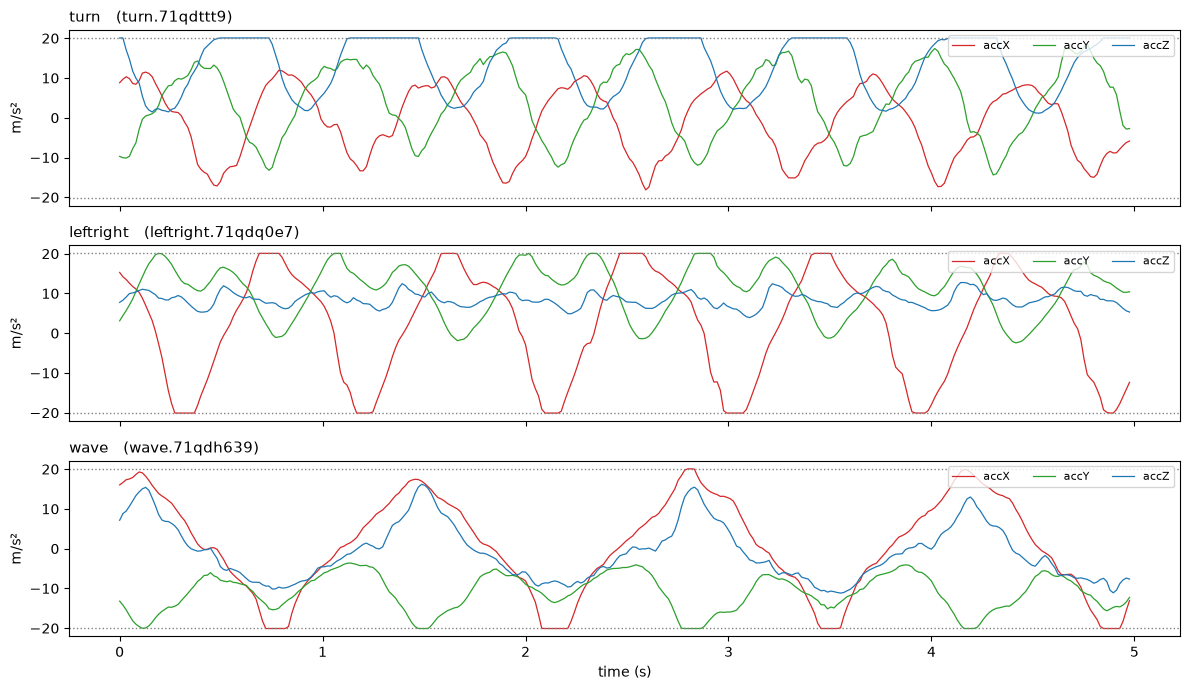

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
time = np.arange(312) / SAMPLE_RATE_HZ

for ax, label in zip(axes, ["turn", "leftright", "wave"]):
    rec = next(r for r in recordings if r.label == label and r.category == "training")
    for i, (axis_name, colour) in enumerate(zip("XYZ", ["#d62728", "#2ca02c", "#1f77b4"])):
        ax.plot(time, rec.values[:, i], color=colour, lw=0.9, label=f"acc{axis_name}")
    ax.axhline(20.08, color="grey", ls=":", lw=1)
    ax.axhline(-20.08, color="grey", ls=":", lw=1)
    ax.set_title(f"{label}   ({rec.name})", loc="left", fontsize=11)
    ax.set_ylabel("m/s²")
    ax.legend(loc="upper right", ncol=3, fontsize=8)

axes[-1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

## 3. Cutting the recordings into windows

The device never sees a whole recording. It keeps a rolling buffer and
classifies it over and over, so that is what we have to train on.

Below is the setting that we will use in this practice to make windows from the whole recordings (Note that you can change this setting to make it suitable with your specific projects).

| setting | value | in samples at 62.5 Hz |
|---|---|---|
| window size | 2000 ms | 125 |
| window increase (stride) | 1000 ms | 63 |
| zero-pad | yes | pad the final short window |

The window converts exactly: 2000 ms at 62.5 Hz is 125 samples. The stride for 1000 ms works out at 62.5 samples, and there is no such thing as half a
sample, so we round to the nearest whole one: 63 samples. Every window then starts at a plain integer index and consecutive windows are evenly spaced.

One warning if you write this yourself. Python's built-in `round()` breaks ties towards the even number, so `round(62.5)` returns 62, not 63. That is why the code below adds 0.5 and truncates instead.

Zero-padding matters for a related reason. A five-second recording does not divide neatly into 2000 ms windows spaced 1008 ms apart, so the last window runs off the end of the data. Rather than throw it away we pad it with zeros and keep it.

In [9]:
import math

FREQ_HZ   = 62.5      # sampling frequency of the recordings
WINDOW_MS = 2000      # window size
STRIDE_MS = 1000      # window increase
ZERO_PAD  = True

# A window position is an array index, so it has to be a whole number of
# samples. Convert from milliseconds and round to the nearest sample.
# Note the "+ 0.5" rather than round(): Python's round() breaks ties towards
# the even number, so round(62.5) would give 62, not 63.
WINDOW = int(WINDOW_MS / 1000 * FREQ_HZ + 0.5)
STRIDE = int(STRIDE_MS / 1000 * FREQ_HZ + 0.5)

print(f"window {WINDOW_MS} ms -> {WINDOW} samples ({WINDOW / FREQ_HZ * 1000:.0f} ms)")
print(f"stride {STRIDE_MS} ms -> {STRIDE} samples ({STRIDE / FREQ_HZ * 1000:.0f} ms)")
print(f"zero-pad: {ZERO_PAD}")

window 2000 ms -> 125 samples (2000 ms)
stride 1000 ms -> 63 samples (1008 ms)
zero-pad: True


In [10]:
def make_windows(values, window=WINDOW, stride=STRIDE, zero_pad=ZERO_PAD):
    """Slide a window along one recording -> (n_windows, window, n_axes).

    Both window and stride are whole numbers of samples, so every start is a
    plain integer index and consecutive windows are evenly spaced.
    """
    n_samples, n_axes = values.shape

    if zero_pad:
        # Keep the final window even though it runs past the end of the data.
        n_windows = math.ceil((n_samples - window) / stride) + 1
    else:
        n_windows = int((n_samples - window) // stride) + 1

    out = []
    for i in range(n_windows):
        start = i * stride
        segment = values[start:start + window]
        if len(segment) < window:
            pad = np.zeros((window - len(segment), n_axes), dtype=np.float32)
            segment = np.vstack([segment, pad])
        out.append(segment)

    return np.stack(out).astype(np.float32)


demo = make_windows(recordings[0].values)
print(f"one recording {recordings[0].values.shape} -> windows {demo.shape}")

one recording (312, 3) -> windows (4, 125, 3)


From the result, for one recording we have totally 312 samples with 3 axes (X, Y, Z). When choosing the number of samples for each window is 125 with stride 63, we can split our recording into 4 windows.

Now every recording. As well as the windows and their labels we keep a `groups`
array recording which file each window came from. We need it later: neighbouring
windows overlap by half their length, so any evaluation has to keep all the
windows of one recording on the same side of a split.

In [11]:
def build_dataset(recordings, category):
    """Window every recording in a split.

    Returns X (windows), y (labels), groups (source recording), names.
    """
    selected = [r for r in recordings if r.category == category]
    X, y, groups, names = [], [], [], []

    for recording_id, rec in enumerate(selected):
        w = make_windows(rec.values)
        X.append(w)
        y.append(np.full(len(w), rec.label))
        groups.append(np.full(len(w), recording_id))
        names.append(rec.name)

    return np.concatenate(X), np.concatenate(y), np.concatenate(groups), names


X_train_win, y_train_str, groups_train, names_train = build_dataset(recordings, "training")
X_test_win,  y_test_str,  groups_test,  names_test  = build_dataset(recordings, "testing")

LABELS = sorted(set(y_train_str))
label_to_index = {name: i for i, name in enumerate(LABELS)}
y_train = np.array([label_to_index[l] for l in y_train_str])
y_test  = np.array([label_to_index[l] for l in y_test_str])

print(f"training windows {X_train_win.shape}  from {len(names_train)} recordings")
print(f"testing  windows {X_test_win.shape}   from {len(names_test)} recordings")
print()
print("classes:", {i: n for n, i in label_to_index.items()})
print("training windows per class:", np.bincount(y_train))

training windows (152, 125, 3)  from 38 recordings
testing  windows (40, 125, 3)   from 10 recordings

classes: {0: 'leftright', 1: 'turn', 2: 'wave'}
training windows per class: [52 48 52]


From the results above, we have 152 windows will be used during the training phase and 40 windows for testing phase, each window contains 125 samples with 3 axes accX, accY, accZ.

## 4. From windows to model input

The model takes one flat vector per window. A window is 125 samples of 3 axes,
so that is 375 numbers, laid out **interleaved**:

```
accX0, accY0, accZ0, accX1, accY1, accZ1, ...
```

This is exactly the order the firmware fills its buffer in, and it is what NumPy
gives you for free when you flatten a `(125, 3)` array, because the last axis
varies fastest. Getting this order wrong produces a model that trains perfectly
and predicts nonsense on hardware, so the cell below prints the first few numbers
both ways so you can see they line up.

In [ ]:
# One window is (125 samples, 3 axes). The model wants it flat.
# reshape(-1) walks the last axis fastest, giving the interleaved layout
# x0,y0,z0, x1,y1,z1, ... which is the order the firmware uses.
X_train = X_train_win.reshape(len(X_train_win), -1).astype(np.float32)
X_test  = X_test_win.reshape(len(X_test_win),  -1).astype(np.float32)

print(f"raw windows   {X_train_win.shape}")
print(f"flattened     {X_train.shape}   ({WINDOW} samples x {N_AXES} axes = {X_train.shape[1]})")
print()

# Proof that the flattening interleaved rather than concatenated the axes.
print("first 2 samples of window 0, as (sample, axis):")
print(X_train_win[0][:2])
print()
print("the same window flattened, first 6 numbers:")
print(X_train[0][:6])

raw windows   (152, 125, 3)
flattened     (152, 375)   (125 samples x 3 axes = 375)

first 2 samples of window 0, as (sample, axis):
[[15.27876   3.118514  7.75706 ]
 [14.200029  4.432605  8.296425]]

the same window flattened, first 6 numbers:
[15.27876   3.118514  7.75706  14.200029  4.432605  8.296425]


Before training on them, look at the windows themselves. Each motion should be
visibly different in at least one axis. If two classes look identical here, no
network is going to separate them either, and the problem is in the data
collection rather than in the model.

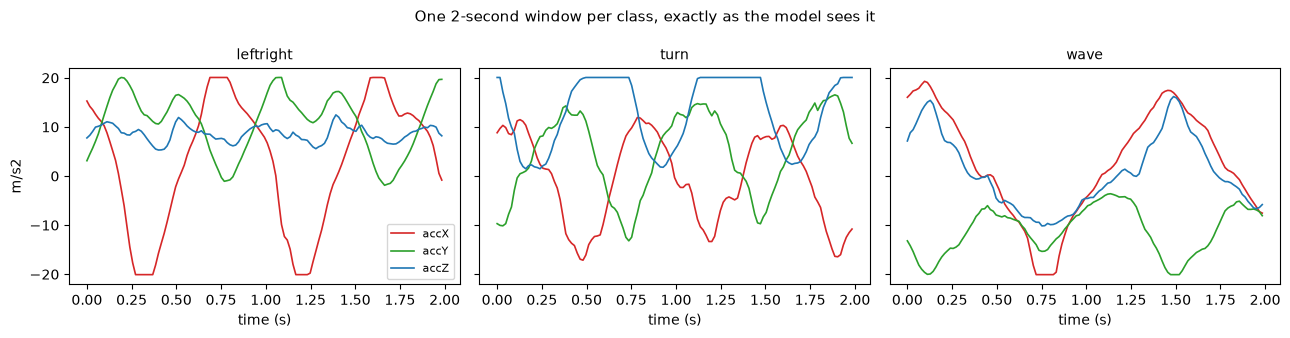

In [ ]:
fig, axs = plt.subplots(1, len(LABELS), figsize=(13, 3.4), sharey=True)
time_axis = np.arange(WINDOW) / FREQ_HZ

for cls, (ax, name) in enumerate(zip(axs, LABELS)):
    window = X_train_win[y_train == cls][0]
    for a, (axis_name, colour) in enumerate(
            zip(("accX", "accY", "accZ"), ["#d62728", "#2ca02c", "#1f77b4"])):
        ax.plot(time_axis, window[:, a], color=colour, lw=1.2, label=axis_name)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("time (s)")

axs[0].set_ylabel("m/s2")
axs[0].legend(fontsize=8)
fig.suptitle("One 2-second window per class, exactly as the model sees it", fontsize=11)
fig.tight_layout()
plt.show()

## 5. The classification model

The network reads a flat 375-number window, folds it back into 125 timesteps of 3 axes, removes gravity, and looks for short movement patterns along the time axis. In this example, we just use a simple network with dense layers 32, 16, 3.

```
Input flatten 375 -> Reshape(125, 3) -> RemoveGravity -> Normalization
    -> Flatten -> Dense(32)
    -> Flatten -> Dense(16) -> Dense(3) softmax
```

**`RemoveGravity`**. It is the constant ~9.81 m/s2 pull of gravity,
split across the three axes.

Subtracting each window's own per-axis mean removes it:

```python
x - tf.reduce_mean(x, axis=1, keepdims=True)
```

**`Normalization`** It scales each axis to a comparable
range so training behaves. Because gravity is already gone the mean is zero, and
only the variance of the *motion* is needed.

In [ ]:
EPOCHS           = 50
LEARNING_RATE    = 0.001
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2


class RemoveGravity(tf.keras.layers.Layer):

    def call(self, x):
        return x - tf.reduce_mean(x, axis=1, keepdims=True)

    def compute_output_shape(self, input_shape):
        return input_shape


# Variance of the MOTION, i.e. measured after gravity is removed, on the
# training windows only. The mean is zero by construction, so it is not
# measured at all. These become constants inside the model.
_centred   = X_train_win - X_train_win.mean(axis=1, keepdims=True)
MOTION_VAR = _centred.reshape(-1, N_AXES).var(axis=0)

print("raw per-axis mean      ", np.round(X_train_win.reshape(-1, N_AXES).mean(axis=0), 2),
      "  <- gravity, varies with how you hold it")
print("motion per-axis std    ", np.round(np.sqrt(MOTION_VAR), 2),
      "  <- what the model actually sees")


def build_classifier(n_inputs, n_classes, variance=None, batch_size=None):
    """flat window -> (125, 3) -> de-gravity -> normalise -> dense
    variance defaults to the whole training set's motion variance; the
    cross-validation below passes its own, measured on that fold only.
    """
    
    variance = MOTION_VAR if variance is None else variance

    # Network architecture
    model = tf.keras.Sequential(name="motion_classifier")
    model.add(tf.keras.layers.Input(shape=(n_inputs,), batch_size=batch_size))
    model.add(tf.keras.layers.Reshape((WINDOW, N_AXES)))
    model.add(RemoveGravity())
    model.add(tf.keras.layers.Normalization(axis=-1, mean=np.zeros(N_AXES), variance=variance))
    model.add(tf.keras.layers.Flatten())                      # back to 375, gravity gone
    model.add(tf.keras.layers.Dense(32, activation="relu"))
    model.add(tf.keras.layers.Dense(16, activation="relu"))
    model.add(tf.keras.layers.Dense(n_classes, activation="softmax"))


    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


build_classifier(X_train.shape[1], len(LABELS)).summary()



raw per-axis mean       [ 1.64 -4.61  8.15]   <- gravity, varies with how you hold it
motion per-axis std     [10.03  8.52  7.12]   <- what the model actually sees


Model: "motion_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_9 (Reshape)             │ (None, 125, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ remove_gravity_5                │ (None, 125, 3)         │             0 │
│ (RemoveGravity)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_9 (Normalization) │ (None, 125, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 375)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,611 (49.26 KB)

 Trainable params: 12,611 (49.26 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [45]:
tf.keras.utils.set_random_seed(SEED)
model = build_classifier(X_train.shape[1], len(LABELS))

# Keras carves the validation split off the END of the arrays and does it BEFORE
# shuffling. Our windows arrive grouped by recording, and the recordings are
# sorted by label, so the last 20% would be a single class. Shuffle first.
rng = np.random.default_rng(SEED)
order = rng.permutation(len(X_train))

history = model.fit(X_train[order], y_train[order],
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=VALIDATION_SPLIT,
                    verbose=0)

print(f"after {EPOCHS} epochs:")
print(f"  training accuracy   {history.history['accuracy'][-1]:.1%}")
print(f"  validation accuracy {history.history['val_accuracy'][-1]:.1%}")

after 50 epochs:
  training accuracy   100.0%
  validation accuracy 93.5%


### Plotting model accuracy and loss

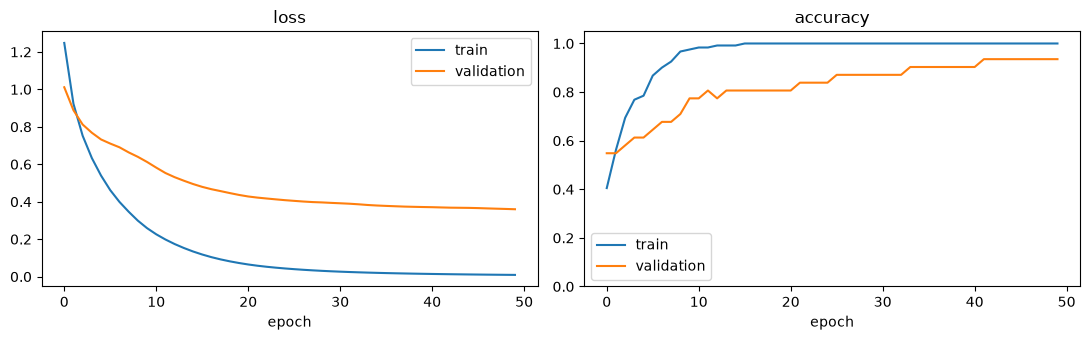

In [54]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.plot(history.history["loss"], label="train")
a1.plot(history.history["val_loss"], label="validation")
a1.set_title("loss"); a1.set_xlabel("epoch"); a1.legend()

a2.plot(history.history["accuracy"], label="train")
a2.plot(history.history["val_accuracy"], label="validation")
a2.set_title("accuracy"); a2.set_xlabel("epoch"); a2.set_ylim(0, 1.05); a2.legend()
fig.tight_layout(); plt.show()

## 6. Model Testing

In [63]:
pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(f"test window accuracy: {accuracy_score(y_test, pred_test):.1%} "
      f"({(pred_test == y_test).sum()}/{len(y_test)} windows)")
print()
print(classification_report(y_test, pred_test, target_names=LABELS, zero_division=0))

test window accuracy: 95.0% (38/40 windows)

              precision    recall  f1-score   support

   leftright       1.00      0.88      0.93        16
        turn       1.00      1.00      1.00        12
        wave       0.86      1.00      0.92        12

    accuracy                           0.95        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.96      0.95      0.95        40



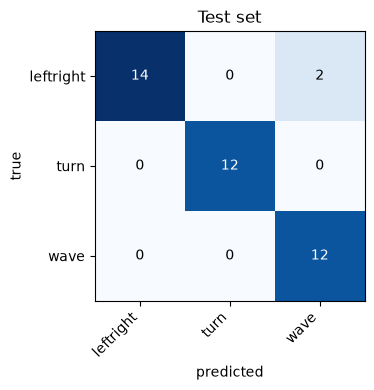

In [48]:
cm = confusion_matrix(y_test, pred_test)

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS)), LABELS)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Test set")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.tight_layout(); plt.show()

## 7. Export model to tflite

A Keras model cannot run directly on Thingy53, so we convert it to TensorFlow Lite and quantize it to int8.

In [ ]:
from pathlib import Path

OUT = Path("artifacts")
OUT.mkdir(exist_ok=True)
export_model = build_classifier(X_train.shape[1], len(LABELS), batch_size=1)
export_model.set_weights(model.get_weights())

def representative_dataset():
    for sample in X_train[:200]:
        yield [sample[None].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
(OUT / "motion_model_int8.tflite").write_bytes(tflite_model)

print(f"int8 model: {len(tflite_model) / 1024:.1f} kB")

INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpnk38fpcw\assets


INFO:tensorflow:Assets written to: C:\Users\Admin\AppData\Local\Temp\tmpnk38fpcw\assets


Saved artifact at 'C:\Users\Admin\AppData\Local\Temp\tmpnk38fpcw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 375), dtype=tf.float32, name='keras_tensor_87')
Output Type:
  TensorSpec(shape=(1, 3), dtype=tf.float32, name=None)
Captures:
  2690209868176: TensorSpec(shape=(1, 1, 3), dtype=tf.float32, name=None)
  2690209867792: TensorSpec(shape=(1, 1, 3), dtype=tf.float32, name=None)
  2690071206736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2690131067920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2690209866064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2690209867216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2690209865872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2690209865680: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\UTwente_Research\TeachingAssistant\IoTs-26\firmware-nordic-thingy53\.venv-ml\Lib\site-packages\tensorflow\lite\python\convert.py:983: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


int8 model: 17.5 kB


Always check that quantising has not changed the answers. The loop below runs
the quantised model and compares it against the original. It also shows the
exact sequence the firmware performs: scale the input to int8, invoke, scale the
output back.

In [61]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

in_scale, in_zero = inp["quantization"]
out_scale, out_zero = out["quantization"]

quantised_pred = []
for sample in X_test:
    q = np.clip(np.round(sample[None] / in_scale + in_zero), -128, 127).astype(np.int8)
    interpreter.set_tensor(inp["index"], q)
    interpreter.invoke()
    probs = (interpreter.get_tensor(out["index"])[0].astype(np.float32) - out_zero) * out_scale
    quantised_pred.append(int(np.argmax(probs)))

quantised_pred = np.array(quantised_pred)
agree = (quantised_pred == pred_test).mean()
print(f"int8 accuracy: {accuracy_score(y_test, quantised_pred):.1%}")
print(f"agreement with the float model: {agree:.1%} of windows")
print(f"Now, your model is saved on  {OUT / 'motion_model_int8.tflite'}")
print("You will use this tflite model and upload to Edge Impulse to generate the build, ready to flash into Thingy53")

int8 accuracy: 92.5%
agreement with the float model: 97.5% of windows
Now, your model is saved on  artifacts\motion_model_int8.tflite
You will use this tflite model and upload to Edge Impulse to generate the build, ready to flash into Thingy53


## Importance
Please go back to the Manual file and continue with the guide of how to upload your tflite model into Edge Impulse to generate the build and how to flash it into Thingy53.

Remember: When Edge Impulse asks to fill in the classes of your model output, the classes must be in order correctly, you can see the order of classes via the cell code below.


In [ ]:
lines = ["// Generated by the motion classification notebook.",
         "#pragma once", "#include <stdint.h>", "",
         f"#define MOTION_MODEL_LEN {len(tflite_model)}",
         f"#define MOTION_MODEL_INPUTS {X_train.shape[1]}",
         f"#define MOTION_MODEL_CLASSES {len(LABELS)}", "",
         "const unsigned char __attribute__((aligned(8))) motion_model[] = {"]
for i in range(0, len(tflite_model), 12):
    lines.append("    " + ", ".join(f"0x{b:02x}" for b in tflite_model[i:i + 12]) + ",")
lines += ["};", ""]
(OUT / "motion_model.h").write_text("\n".join(lines))

print(f"saved  {OUT / 'motion_model_int8.tflite'}")
print(f"saved  {OUT / 'motion_model.h'}   ({len(lines)} lines of C)")
print()
print("classes, in the order the model outputs them:", LABELS)

saved  artifacts\motion_model_int8.tflite
saved  artifacts\motion_model.h   (1500 lines of C)

classes, in the order the model outputs them: ['leftright', 'turn', 'wave']


## Summary

The pipeline you just built, end to end:

| stage | what happens |
|---|---|
| input | 3 axes (accX, accY, accZ) at 62.5 Hz |
| windowing | 2000 ms windows, 1000 ms stride, zero-padded |
| model input | 375 raw interleaved values, no external preprocessing |
| preprocessing | de-gravity, reshape, normalisation — **all layers inside the model** |
| classifier | Dense(32) -> Dense(16) -> 3 |
| training | 50 epochs, learning rate 0.001, batch 32, 20% validation |
| export | int8 TFLite |